# Stage 1: Single Hopf Oscillator


## The Model

A single uncoupled node obeys the Hopf normal form:

$$\dot{z} = z\,(\lambda + i\omega - |z|^2)$$

where $z = x + iy$, which expands to:

$$\dot{x} = x(\lambda - r^2) - \omega\, y$$
$$\dot{y} = y(\lambda - r^2) + \omega\, x$$

with $r^2 = x^2 + y^2$.

**Key behaviour:**
- $\lambda < 0$: stable fixed point at the origin — oscillations decay
- $\lambda = 0$: **Hopf bifurcation** (critical point)
- $\lambda > 0$: stable limit cycle with radius $|z| = \sqrt{\lambda}$ and angular frequency $\omega$



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

%matplotlib inline
plt.rcParams.update({"figure.dpi": 120, "font.size": 11})


# Hopf model

def hopf_rhs(_t, state, _N, W, K, lam, C, omega):
    """Coupled Hopf oscillator ODE. State: [x1, y1, ..., xN, yN]."""
    x, y = state[0::2], state[1::2]
    r2 = x**2 + y**2
    dx = x * (lam - r2) - omega * y + K * np.tanh(C * W @ x)
    dy = y * (lam - r2) + omega * x
    out = np.empty_like(state)
    out[0::2], out[1::2] = dx, dy
    return out


def simulate_hopf(N, W, K, lam, C, omega, z0,
                  t_total=14.5, t_discard=1.0, fs=1250):
    """Integrate the Hopf model, discard transient, return (t, x, y)."""
    if np.iscomplexobj(z0):
        state0 = np.empty(2 * N)
        state0[0::2], state0[1::2] = z0.real, z0.imag
    else:
        state0 = np.asarray(z0, dtype=float)

    sol = solve_ivp(
        hopf_rhs, (0.0, t_total), state0,
        t_eval=np.arange(t_discard, t_total, 1.0 / fs),
        args=(N, W, K, lam, C, omega),
    )
    if sol.status != 0:
        raise RuntimeError(f"ODE solver failed: {sol.message}")
    return sol.t - t_discard, sol.y[0::2], sol.y[1::2]


def random_initial_conditions(N, rng=None):
    """Sample N complex values uniformly in the unit disk."""
    if not isinstance(rng, np.random.Generator):
        rng = np.random.default_rng(rng)
    r = np.sqrt(rng.uniform(0, 1, N))
    theta = rng.uniform(0, 2 * np.pi, N)
    return r * np.exp(1j * theta)


## 1. Simulate a single uncoupled oscillator

We use the general N-node solver with N=1, K=0 (no coupling), and a dummy 1×1 adjacency matrix.

In [ ]:
def simulate_single(lam, omega_hz=10.0, z0=None, t_total=14.5, t_discard=1.0, fs=1250):
    """Simulate one uncoupled Hopf oscillator."""
    omega = 2 * np.pi * omega_hz
    if z0 is None:
        z0 = random_initial_conditions(1, rng=42)
    elif np.isscalar(z0):
        z0 = np.array([z0], dtype=complex)
    t, x, y = simulate_hopf(
        N=1, W=np.zeros((1, 1)), K=0.0, lam=lam, C=0.0,
        omega=np.array([omega]), z0=z0,
        t_total=t_total, t_discard=t_discard, fs=fs,
    )
    return t, x[0], y[0]

## 2. Time series for different $\lambda$

We simulate the oscillator for subcritical ($\lambda < 0$), critical ($\lambda = 0$),
and supercritical ($\lambda > 0$) regimes.

For $\lambda > 0$ the real part $x(t)$ settles onto a sinusoidal limit cycle with
amplitude $\sqrt{\lambda}$.

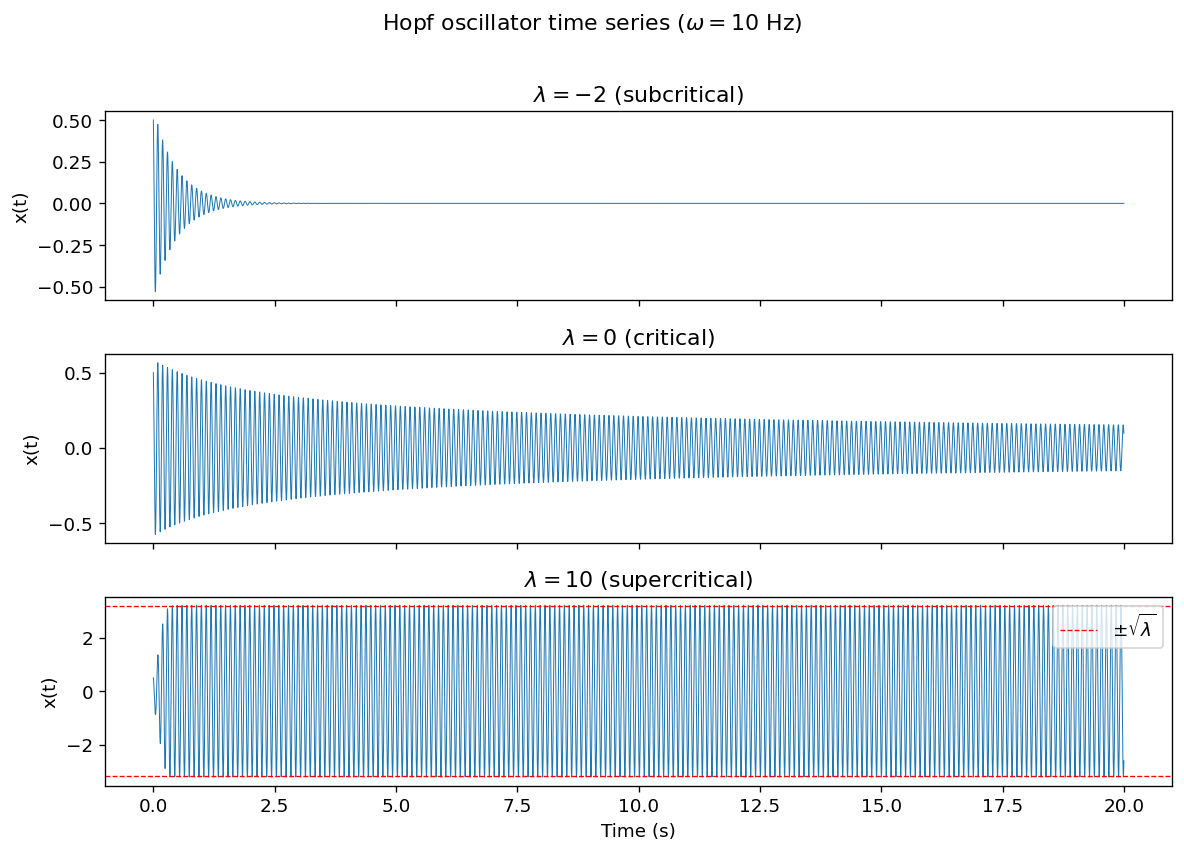

In [3]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)

z0_start = np.array([0.5 + 0.3j])

for ax, lam, label in zip(axes, [-2.0, 0.0, 10.0],
                          [r"$\lambda = -2$ (subcritical)",
                           r"$\lambda = 0$ (critical)",
                           r"$\lambda = 10$ (supercritical)"]):
    t, x, y = simulate_single(lam, z0=z0_start, t_discard=0.0,t_total=20)
    ax.plot(t, x, linewidth=0.6)
    ax.set_ylabel("x(t)")
    ax.set_title(label)
    if lam > 0:
        ax.axhline(np.sqrt(lam), color="red", ls="--", lw=0.8, label=r"$\pm\sqrt{\lambda}$")
        ax.axhline(-np.sqrt(lam), color="red", ls="--", lw=0.8)
        ax.legend(loc="upper right")

axes[-1].set_xlabel("Time (s)")
fig.suptitle("Hopf oscillator time series ($\\omega = 10$ Hz)", y=1.01)
fig.tight_layout()

## 3. Phase portraits

Plotting the trajectory in the $(x, y)$ plane shows:
- **Subcritical**: spiral into the origin
- **Critical**: slow decay toward zero
- **Supercritical**: spiral outward onto a circle of radius $\sqrt{\lambda}$

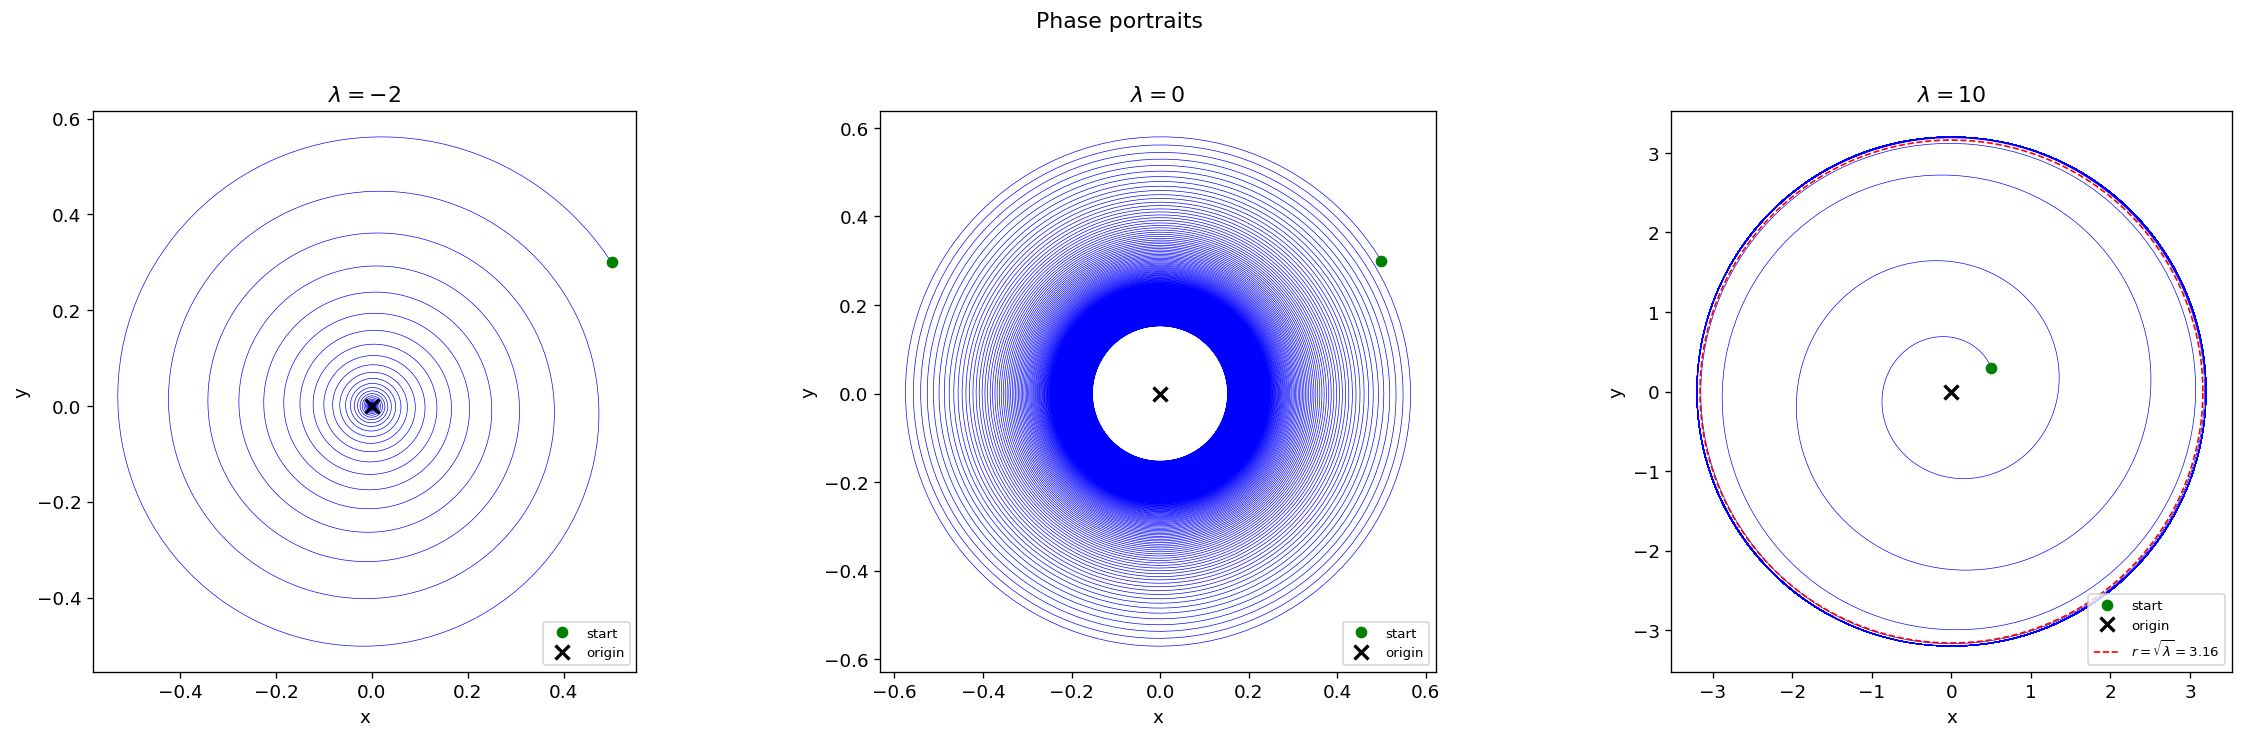

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

z0_start = np.array([0.5 + 0.3j])

for ax, lam, title in zip(axes, [-2.0, 0.0, 10.0],
                          [r"$\lambda=-2$", r"$\lambda=0$", r"$\lambda=10$"]):
    t, x, y = simulate_single(lam, z0=z0_start, t_total=20.0, t_discard=0.0)
    ax.plot(x, y, linewidth=0.4, color="blue")
    ax.plot(x[0], y[0], "go", ms=6, label="start")
    ax.plot(0, 0, "kx", ms=8, mew=2, label="origin")
    if lam > 0:
        theta_circle = np.linspace(0, 2 * np.pi, 200)
        r = np.sqrt(lam)
        ax.plot(r * np.cos(theta_circle), r * np.sin(theta_circle),
               "r--", lw=1, label=rf"$r=\sqrt{{\lambda}}={r:.2f}$")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_aspect("equal")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="lower right")

fig.suptitle("Phase portraits", y=1.02)
fig.tight_layout()

## 4. Bifurcation diagram

We plot $\lambda$ from $-5$ to $+50$ and measure the steady-state amplitude
$|z|_{\text{ss}}$.

C:\Users\Bob Rice\AppData\Local\Temp\ipykernel_15160\2701702802.py:12: RuntimeWarning: invalid value encountered in sqrt
  theory = np.where(lam_values > 0, np.sqrt(lam_values), 0.0)


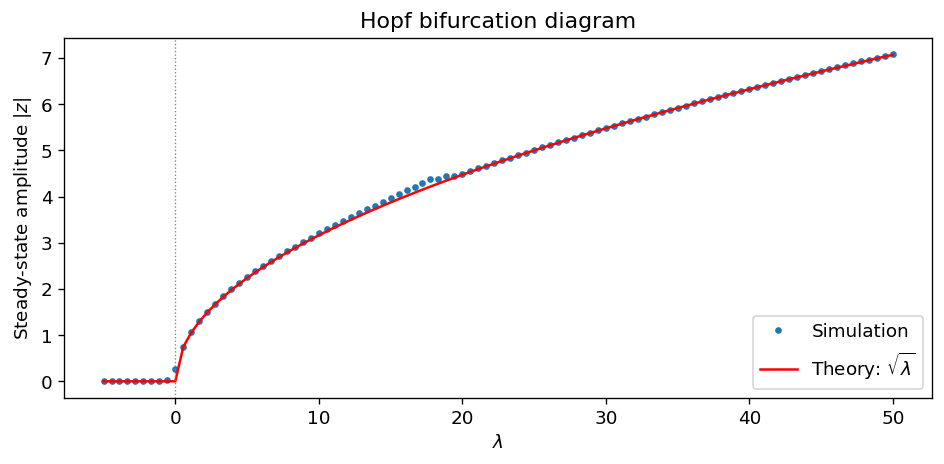

In [5]:
lam_values = np.linspace(-5, 50, 100)
amplitudes = []

z0_start = np.array([0.5 + 0.3j])

for lam in lam_values:
    t, x, y = simulate_single(lam, z0=z0_start, t_total=6.0, t_discard=4.0)
    r = np.sqrt(x**2 + y**2)
    amplitudes.append(np.mean(r[-len(r)//4:]))  # average over last quarter

amplitudes = np.array(amplitudes)
theory = np.where(lam_values > 0, np.sqrt(lam_values), 0.0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lam_values, amplitudes, "o", ms=3, label="Simulation")
ax.plot(lam_values, theory, "r-", lw=1.5, label=r"Theory: $\sqrt{\lambda}$")
ax.axvline(0, color="grey", ls=":", lw=0.8)
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel(r"Steady-state amplitude $|z|$")
ax.set_title("Hopf bifurcation diagram")
ax.legend()
fig.tight_layout()

## 5. Frequency verification via FFT

We verify that the oscillation frequency matches the prescribed natural frequency
$\omega / (2\pi)$ by examining the power spectrum.

Prescribed frequency: 10.0 Hz
Measured peak frequency: 10.0000 Hz


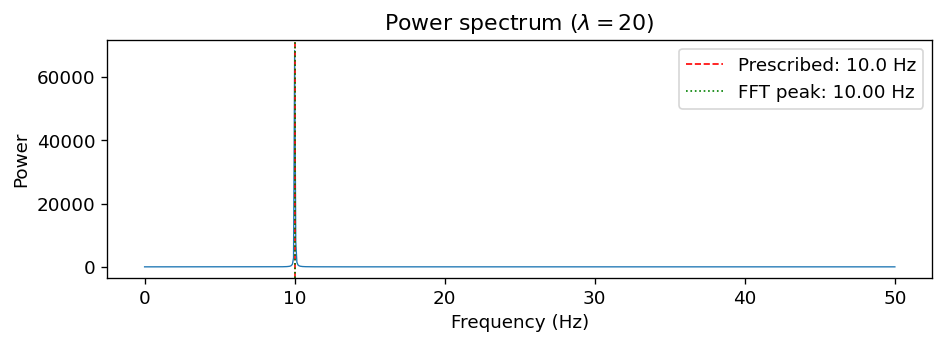

In [6]:
omega_hz = 10.0
fs = 1250

t, x, y = simulate_single(lam=20.0, omega_hz=omega_hz, z0=np.array([0.1 + 0.1j]))

freqs = np.fft.rfftfreq(len(x), d=1.0 / fs)
power = np.abs(np.fft.rfft(x)) ** 2 / len(x)
peak_freq = freqs[np.argmax(power[1:]) + 1]  # skip DC

fig, ax = plt.subplots(figsize=(8, 3))
mask = freqs <= 50
ax.plot(freqs[mask], power[mask], linewidth=0.8)
ax.axvline(omega_hz, color="red", ls="--", lw=1, label=f"Prescribed: {omega_hz} Hz")
ax.axvline(peak_freq, color="green", ls=":", lw=1, label=f"FFT peak: {peak_freq:.2f} Hz")
ax.set_xlabel("Frequency (Hz)")
ax.set_ylabel("Power")
ax.set_title(r"Power spectrum ($\lambda=20$)")
ax.legend()
fig.tight_layout()
print(f"Prescribed frequency: {omega_hz} Hz")
print(f"Measured peak frequency: {peak_freq:.4f} Hz")

## 6. Amplitude depends on $\lambda$, frequency does not

An important property: for $\lambda > 0$, changing $\lambda$ changes the **amplitude**
of the limit cycle ($\sqrt{\lambda}$) but not the **frequency** (which is set by $\omega$).
This is why the paper's rescaling $\tilde{x}_i = \sqrt{\lambda}\, x_i$ normalises
the limit-cycle radius to 1.

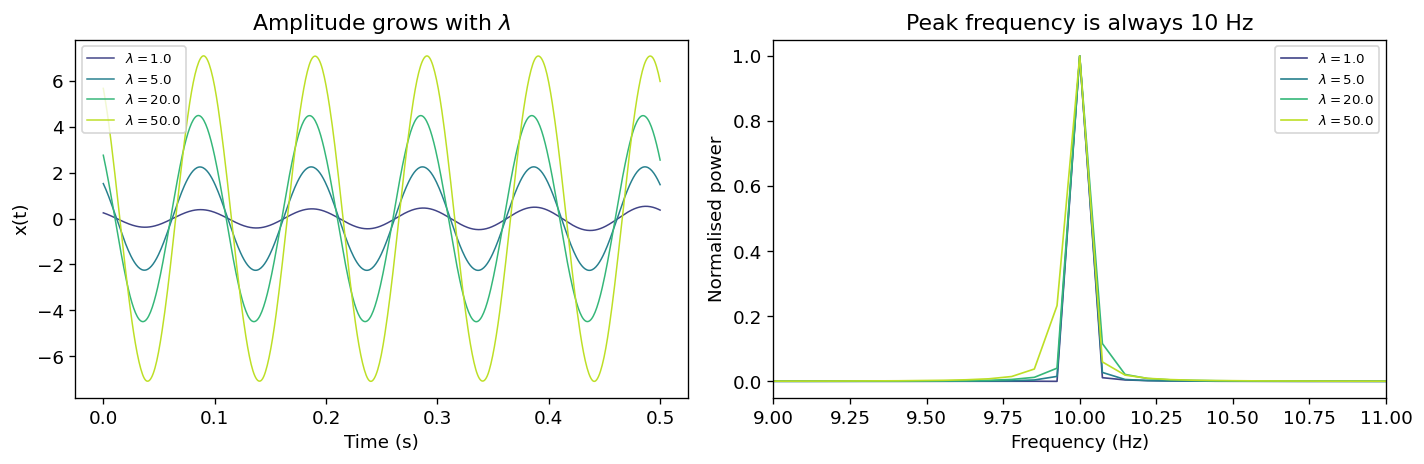

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

lam_test = [1.0, 5.0, 20.0, 50.0]
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(lam_test)))

for lam, col in zip(lam_test, colors):
    t, x, y = simulate_single(lam, omega_hz=10.0, z0=np.array([0.1 + 0.1j]))

    # Time series (show 0.5 s window)
    win = t <= 0.5
    axes[0].plot(t[win], x[win], color=col, lw=0.9, label=rf"$\lambda={lam}$")

    # Power spectrum
    freqs = np.fft.rfftfreq(len(x), d=1.0 / 1250)
    power = np.abs(np.fft.rfft(x)) ** 2 / len(x)
    fmask = (freqs >= 5) & (freqs <= 15)
    axes[1].plot(freqs[fmask], power[fmask] / power[fmask].max(),
                 color=col, lw=1, label=rf"$\lambda={lam}$")

axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("x(t)")
axes[0].set_title("Amplitude grows with $\\lambda$")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Normalised power")
axes[1].set_title("Peak frequency is always 10 Hz")
axes[1].set_xlim(9, 11)
axes[1].legend(fontsize=8)

fig.tight_layout()